In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     
df = pd.read_csv("data/titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Para analizar el dataframe usamos shape que regresa el numero de Filas y COlumnas

In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Para limpieza de datos pondremos valores por defecto a Age:la media de edad de todos , Cabin:Cnada, EMbarked: "Embarked"

In [7]:
df = df.fillna({"Age": df["Age"].median(), "Embarked": df["Embarked"].mode()[0], "Cabin": "Unknown"})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Podemos hacer segregacion x genero

In [13]:
df_generos = df.groupby("Sex")
df_generos.describe()
df_generos = df.groupby("Sex").agg({
    "Survived": "mean"})
df_generos



,Survived
Sex,
female,0.742038
male,0.188908


Graficando

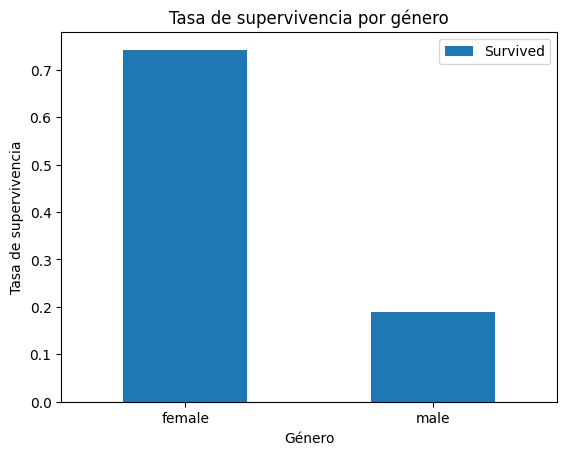

In [14]:
df_generos.plot(kind="bar")
plt.title("Tasa de supervivencia por género")
plt.ylabel("Tasa de supervivencia")
plt.xlabel("Género")
plt.xticks(rotation=0)
plt.show()

In [17]:
fallecidos = df.query("Survived == 0")
fallecidos.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,549.000000,549.0,549.000000,549.000000,549.000000,549.000000,549.000000
mean,447.016393,0.0,2.531876,30.028233,0.553734,0.329690,22.117887
std,260.640469,0.0,0.735805,12.499986,1.288399,0.823166,31.388207
min,1.000000,0.0,1.000000,1.000000,0.000000,0.000000,0.000000
25%,211.000000,0.0,2.000000,23.000000,0.000000,0.000000,7.854200
50%,455.000000,0.0,3.000000,28.000000,0.000000,0.000000,10.500000
75%,675.000000,0.0,3.000000,35.000000,1.000000,0.000000,26.000000
max,891.000000,0.0,3.000000,74.000000,8.000000,6.000000,263.000000


In [18]:
pasajeros = df.shape[0]
pasajeros

891

In [19]:

df_generos = df.groupby("Sex")
df_generos.describe()

PassengerId                                                             \
             count        mean         std  min     25%    50%     75%    max   
Sex                                                                             
female       314.0  431.028662  256.846324  2.0  231.75  414.5  641.25  889.0   
male         577.0  454.147314  257.486139  1.0  222.00  464.0  680.00  891.0   

       Survived            ... Parch        Fare                              \
          count      mean  ...   75%  max  count       mean        std   min   
Sex                        ...                                                 
female    314.0  0.742038  ...   1.0  6.0  314.0  44.479818  57.997698  6.75   
male      577.0  0.188908  ...   0.0  5.0  577.0  25.523893  43.138263  0.00   

                                          
              25%   50%    75%       max  
Sex                                       
female  12.071875  23.0  55.00  512.3292  
male     7.895800  10.5  26.55  512.3292  

[2 rows x 56 columns]

Vamos a utilizar código para extraer datos Quiero los pasajeros totales Supervivientes = 1 Fallecidos = 0

In [20]:

pasajeros = df.shape[0]
supervivientes = df[ df.Survived == 1 ]
num_survided = supervivientes.shape[0]
fallecidos = df.query("Survived == 0")
num_fallecidos = fallecidos.shape[0]
print(f"Pasajeros totales: {pasajeros}")
print(f"Supervivientes: {num_survided}")
print(f"Fallecidos: {num_fallecidos}")

Pasajeros totales: 891
Supervivientes: 342
Fallecidos: 549


Vamos a crear un gráfico PIE con estos datos Para ello, debemos llevar estas variables a un diccionario

In [21]:

data = {
    'Datos': ['Pasajeros totales', 'Supervivientes', 'Fallecidos'],
    'Valores': [pasajeros, num_survided, num_fallecidos]
}
df_datos = pd.DataFrame.from_dict(data)
df_datos

,Datos,Valores
0,Pasajeros totales,891
1,Supervivientes,342
2,Fallecidos,549


<Axes: >

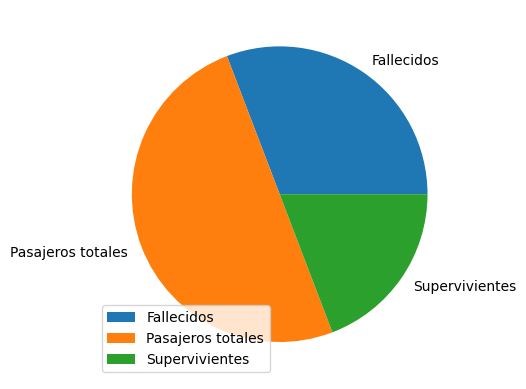

In [22]:

df_datos.groupby("Datos").sum().plot(kind='pie', y='Valores')